# IND320 Assignment 1

## Tasks

### 1 GitHub and Streamlit.app accounts
1.1 GitHub repository can be found [Here](https://github.com/ptilrem/ptilrem-D2D-SLapp/tree/main)

1.2 Logged in to share.streamlit.io

1.3 Streamlit app can be found [Here](https://ptilrem-d2d-slapp.streamlit.app/)

### 2 Jupyter Notebook

#### 2.1 Reading the reservoirs.csv file using Pandas

In [1]:
# Importing necessary libraries
import pandas as pd

In [2]:
# Reading the data to pandas dataframe
df = pd.read_csv("../data/reservoirs.csv")

#### 2.2 Rename headers to English

In [ ]:
# Creating a rename dictionary to rename the columns
column_rename_dict = {
    'dato_Id': 'date_id',
    'omrType': 'area_type',
    'omrnr': 'area_number',
    'iso_aar': 'iso_year',
    'iso_uke': 'iso_week',
    'fyllingsgrad': 'fill_percentage',
    'kapasitet_TWh': 'capacity_TWh',
    'fylling_TWh': 'stored_energy_TWh', # Unsure. Energifylling: Described as capacity times fill percentage
    'neste_Publiseringsdato': 'next_publish_date',
    'fyllingsgrad_forrige_uke': 'fill_percentage_last_week',
    'endring_fyllingsgrad': 'change_fill_percentage'
}

df = df.rename(columns=column_rename_dict)

#### 2.3 Print contents in a relevant way

In [4]:
# Print the head of the dataframe to check new column names and their values
df.head()

,date_id,area_type,area_number,iso_year,iso_week,fill_percentage,capacity_TWh,stored_energy_TWh,next_publish_date,fill_percentage_last_week,change_fill_percentage
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [5]:
# Print the info of the dataframe to check the data types
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14877 entries, 0 to 14876
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date_id                    14877 non-null  str    
 1   area_type                  14877 non-null  str    
 2   area_number                14877 non-null  int64  
 3   iso_year                   14877 non-null  int64  
 4   iso_week                   14877 non-null  int64  
 5   fill_percentage            14877 non-null  float64
 6   capacity_TWh               14877 non-null  float64
 7   stored_energy_TWh          14877 non-null  float64
 8   next_publish_date          14877 non-null  str    
 9   fill_percentage_last_week  14877 non-null  float64
 10  change_fill_percentage     14877 non-null  float64
dtypes: float64(5), int64(3), str(3)
memory usage: 1.7 MB


In [6]:
# Print statistics of the dataframe to see the distrivution
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area_number,14877.0,2.333333,1.490762,0.000000,1.000000,2.000000,3.000000,5.000000
iso_year,14877.0,2010.346038,9.146696,1995.000000,2002.000000,2010.000000,2018.000000,2026.000000
iso_week,14877.0,26.405929,15.017910,1.000000,13.000000,26.000000,39.000000,53.000000
fill_percentage,14877.0,0.618852,0.214850,0.055160,0.456234,0.648049,0.802135,1.020072
capacity_TWh,14877.0,29.145860,22.739070,6.003264,17.390587,23.237715,34.043590,87.437580
stored_energy_TWh,14877.0,18.139713,15.966211,0.331142,7.321973,14.501389,22.203530,84.544820
fill_percentage_last_week,14877.0,0.618890,0.214843,0.055160,0.456356,0.648114,0.802133,1.020037
change_fill_percentage,14877.0,-0.000038,0.031385,-0.242484,-0.022395,-0.007072,0.016277,0.336623


#### 2.4 Plot each column separately

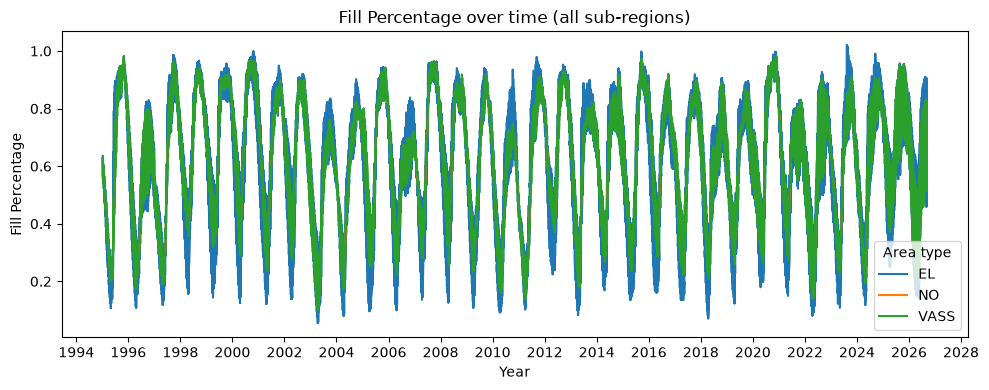

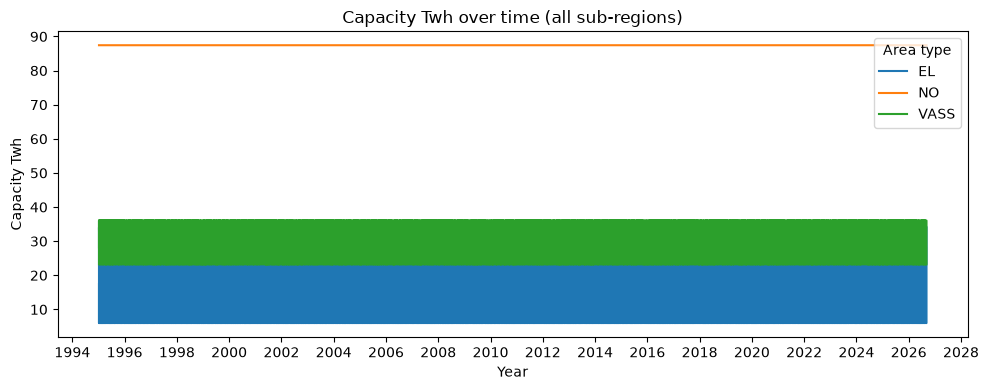

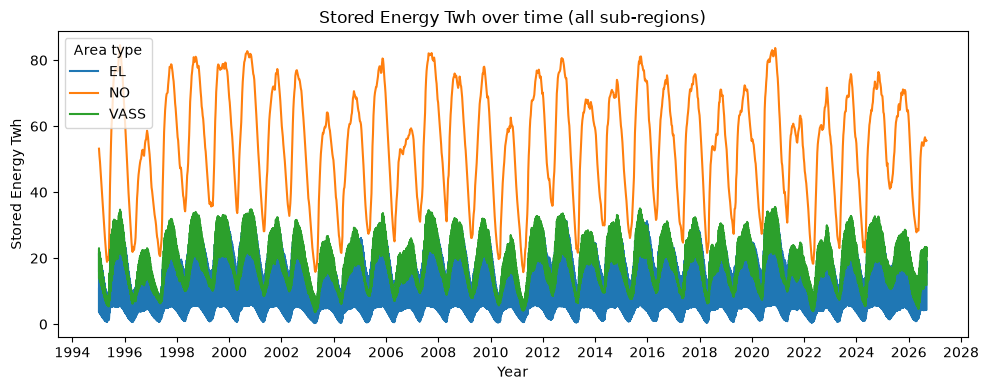

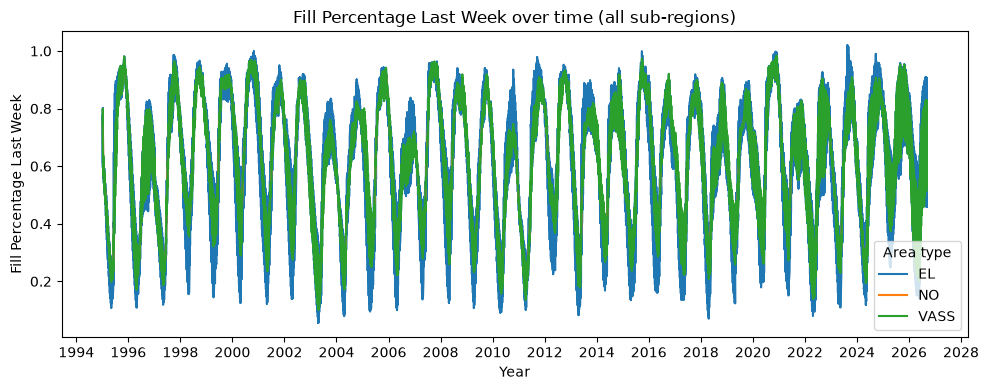

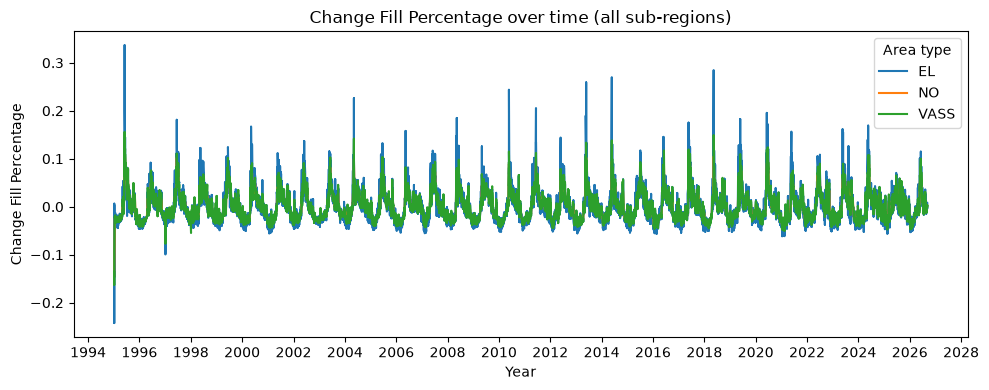

In [7]:
# Import necessary library
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Only plotting the float columns, as the others are either categorical or identifiers
measurement_columns = [
    'fill_percentage',
    'capacity_TWh',
    'stored_energy_TWh',
    'fill_percentage_last_week',
    'change_fill_percentage',
]

# Convert the date_id column to datetime format to avoid plotting errors
df['date_id'] = pd.to_datetime(df['date_id'])

# Sort by date so lines are drawn chronologically,
# without this matplotlib will just draw scribbles
df = df.sort_values('date_id')

# One plot per column, one line per region (area_type), so overlapping
# data is at least grouped rather than pure visual noise
for col in measurement_columns:
    fig, ax = plt.subplots(figsize=(10, 4))

    for area, group in df.groupby('area_type'):
        ax.plot(group['date_id'], group[col], label=area)

    # Only show one tick every other year, labeled just with the year,
    # instead of matplotlib cramming in every individual date.
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

    ax.set_title(f'{col.replace("_", " ").title()} over time (all sub-regions)')
    ax.set_xlabel('Year')
    ax.set_ylabel(col.replace('_', ' ').title())
    ax.legend(title='Area type')
    plt.tight_layout()
    plt.show()

#### 2.5 Plot all columns together

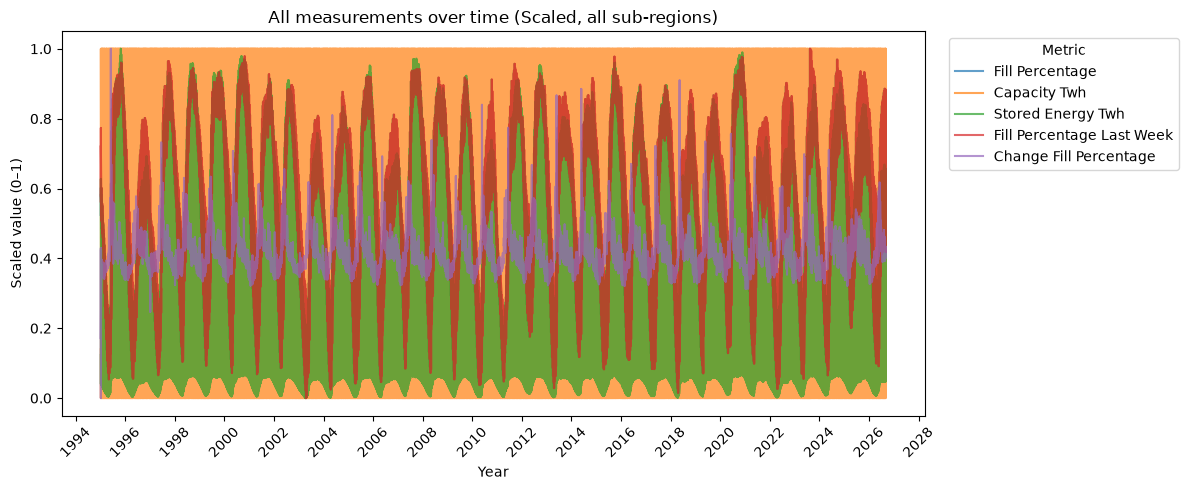

In [ ]:
# Scale each measurement column to 0-1 range so they're
# comparable on one plot despite different units/magnitudes
# (percentages vs. TWh).
df_scaled = df.copy()
for col in measurement_columns:
    col_min, col_max = df[col].min(), df[col].max()
    df_scaled[col] = (df[col] - col_min) / (col_max - col_min)

fig, ax = plt.subplots(figsize=(12, 5))

for col in measurement_columns:
    ax.plot(df_scaled['date_id'], df_scaled[col], label=col.replace('_', ' ').title(), alpha=0.7)

# Same year-interval tick fix as the individual plots, so dates
# stay readable instead of merging into a solid line.
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

ax.set_title('All measurements over time (Scaled, all sub-regions)')
ax.set_xlabel('Year')
ax.set_ylabel('Scaled value (0–1)')
ax.legend(title='Metric', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 3 Streamlit app

#### 3.1 See requirements.txt in GitHub repository. The current requirements.txt file includes the necessary libraries plus all of their dependencies from using 'pip freeze > requirements.txt', but will be stripped down to only the libraries imported/installed later, as the dependencies are installed along with them automatically.

#### 3.2 The four pages were set up as dummy pages first with separate .py files in the "pages" folder

### Use of AI
Generative AI has been used mostly for debugging code, especially the plots, helping make them more readable

Models used:
* Claude Sonnet 5
* GitHub Copilot

Uses:
* Notebook syntax (adding links)
* Auto-fill text when renaming headers
* Debugging errors
* Helping make plots look cleaner